In [1]:
import torch
import torch.nn as nn

from collections import Counter

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [2]:
import pandas as pd

train_df = pd.read_csv("../dataset/train.csv")
test_df = pd.read_csv("../dataset/test.csv")

print(train_df.shape)
print(test_df.shape)

(14294, 2)
(3574, 2)


In [ ]:
#Membuat kamus Vocab dari data training

counter = Counter()

for text in train_df["text"]:
    counter.update(text.split())

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, freq in counter.items():

    if freq >= 2:

        vocab[word] = len(vocab)

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 12202


In [4]:
def encode_text(text, vocab):

    return [
        vocab.get(word, vocab["<UNK>"])
        for word in text.split()
    ]

train_sequences = [
    encode_text(text, vocab)
    for text in train_df["text"]
]

test_sequences = [
    encode_text(text, vocab)
    for text in test_df["text"]
]

In [5]:
lengths = [len(seq) for seq in train_sequences]

print("Max Length:", max(lengths))

print("Average Length:",
      sum(lengths)/len(lengths))

Max Length: 1349
Average Length: 18.242549321393593


In [ ]:
#padding

MAX_LEN = 100

def pad_sequence(sequence, max_len=MAX_LEN):

    if len(sequence) < max_len:

        sequence += [0] * (max_len - len(sequence))

    else:

        sequence = sequence[:max_len]

    return sequence

train_sequences = [
    pad_sequence(seq)
    for seq in train_sequences
]

test_sequences = [
    pad_sequence(seq)
    for seq in test_sequences
]

In [7]:
X_train = torch.tensor(
    train_sequences,
    dtype=torch.long
)

X_test = torch.tensor(
    test_sequences,
    dtype=torch.long
)

y_train = torch.tensor(
    train_df["label"].values,
    dtype=torch.long
)

y_test = torch.tensor(
    test_df["label"].values,
    dtype=torch.long
)

In [ ]:
from torch.utils.data import Dataset

#simpan komen, label yang sudah di encode agar kompatibel dengan dataloader
class YouTubeDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [9]:
from torch.utils.data import DataLoader

train_dataset = YouTubeDataset(
    X_train,
    y_train
)

test_dataset = YouTubeDataset(
    X_test,
    y_test
)



In [ ]:
#dataset dibagi menjadi 64 batch

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [11]:
for X_batch, y_batch in train_loader:

    print(X_batch.shape)

    print(y_batch.shape)

    break

torch.Size([64, 100])
torch.Size([64])


In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [ ]:
#mengatasi data yang tidak seimbang (positive lebih besar dari pada sentiment lainnya)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train.numpy()),
    y=y_train.numpy()
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print(class_weights)

tensor([2.5699, 1.3239, 0.5389])


In [14]:
import torch
import torch.nn as nn
import numpy as np

from collections import Counter

from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# Embedding → BiLSTM → CNN → Pooling → Dense Layer

class RCNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.bilstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.conv = nn.Conv1d(
            in_channels=hidden_dim * 2,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.AdaptiveMaxPool1d(1)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(
            128,
            64
        )

        self.fc2 = nn.Linear(
            64,
            num_classes
        )

    def forward(self, x):

        x = self.embedding(x)
        lstm_out, _ = self.bilstm(x)
        x = lstm_out.permute(0, 2, 1)
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.squeeze(2)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [ ]:
# set parameter model

VOCAB_SIZE = len(vocab)
EMBED_DIM = 100
HIDDEN_DIM = 128
NUM_CLASSES = 3

In [17]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [ ]:
#buat dan pindahkan model ke cpu

model = RCNN(
    VOCAB_SIZE,
    EMBED_DIM,
    HIDDEN_DIM,
    NUM_CLASSES
).to(device)

In [ ]:
# mengukur kesalahan prediksi pada klasifikasi tiga kelas (positif, netral, negatif), Adam Optimizer digunakan untuk memperbarui 
# bobot model selama training dengan learning rate 0.001 agar proses pembelajaran lebih stabil dan efisien.

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:

for X_batch, y_batch in train_loader:

    X_batch = X_batch.to(device)

    outputs = model(X_batch)

    print(outputs.shape)

    break

torch.Size([64, 3])


In [21]:
def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0

    correct = 0

    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += y_batch.size(0)

        correct += (
            predicted == y_batch
        ).sum().item()

    accuracy = (
        100 * correct / total
    )

    return (
        total_loss / len(train_loader),
        accuracy
    )

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(
    model,
    test_loader,
    device
):

    model.eval()

    y_true = []

    y_pred = []

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            _, predicted = torch.max(
                outputs,
                1
            )

            y_true.extend(
                y_batch.numpy()
            )

            y_pred.extend(
                predicted.cpu().numpy()
            )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    return (
        acc,
        precision,
        recall,
        f1,
        y_true,
        y_pred
    )

In [23]:
EPOCHS = 10

history = []

In [24]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_model(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    acc, precision, recall, f1, _, _ = evaluate_model(
        model,
        test_loader,
        device
    )

    history.append([
        epoch + 1,
        train_loss,
        train_acc,
        acc,
        precision,
        recall,
        f1
    ])

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Test Acc: {acc:.4f} "
        f"F1: {f1:.4f}"
    )

Epoch [1/10] Loss: 0.9474 Train Acc: 57.72% Test Acc: 0.6130 F1: 0.6459
Epoch [2/10] Loss: 0.7579 Train Acc: 68.25% Test Acc: 0.6978 F1: 0.7105
Epoch [3/10] Loss: 0.6135 Train Acc: 75.38% Test Acc: 0.7037 F1: 0.7181
Epoch [4/10] Loss: 0.4739 Train Acc: 81.52% Test Acc: 0.6900 F1: 0.7053
Epoch [5/10] Loss: 0.3467 Train Acc: 86.22% Test Acc: 0.7079 F1: 0.7203
Epoch [6/10] Loss: 0.2501 Train Acc: 90.32% Test Acc: 0.7163 F1: 0.7248
Epoch [7/10] Loss: 0.1821 Train Acc: 92.68% Test Acc: 0.7224 F1: 0.7259
Epoch [8/10] Loss: 0.1351 Train Acc: 94.57% Test Acc: 0.7255 F1: 0.7322
Epoch [9/10] Loss: 0.0979 Train Acc: 96.25% Test Acc: 0.7361 F1: 0.7315
Epoch [10/10] Loss: 0.0722 Train Acc: 97.08% Test Acc: 0.7238 F1: 0.7278


In [31]:
acc, precision, recall, f1, y_true, y_pred = evaluate_model(
    model,
    test_loader,
    device
)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7238388360380527
Precision: 0.7329506340479829
Recall   : 0.7238388360380527
F1 Score : 0.7278077964979659


In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.49      0.56      0.53       463
     neutral       0.55      0.57      0.56       900
    positive       0.86      0.82      0.84      2211

    accuracy                           0.72      3574
   macro avg       0.63      0.65      0.64      3574
weighted avg       0.73      0.72      0.73      3574



In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

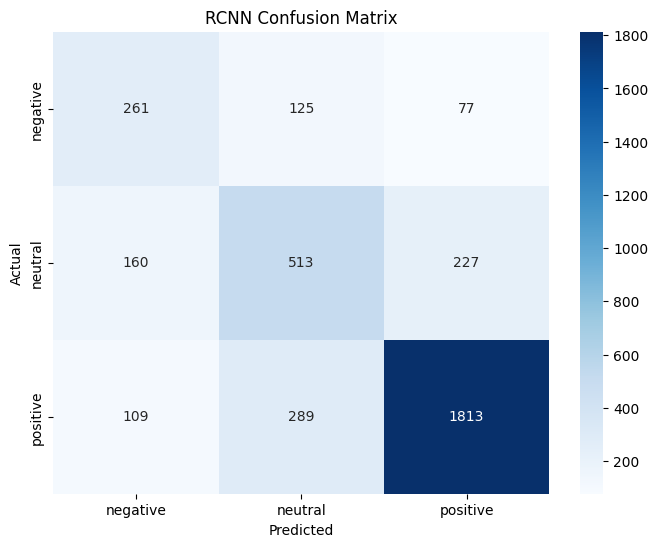

In [28]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "negative",
        "neutral",
        "positive"
    ],
    yticklabels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("RCNN Confusion Matrix")

plt.show()

In [29]:
torch.save(
    model.state_dict(),
    "../models/rcnn_model.pth"
)

In [30]:
import pickle

with open(
    "../models/vocab.pkl",
    "wb"
) as f:

    pickle.dump(
        vocab,
        f
    )